In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from sklearn.metrics import confusion_matrix

In [7]:
# MNIST IMAGE --> Tensors

In [8]:
transform = transforms.ToTensor()

In [11]:
train_data = datasets.MNIST(root='../Data', train=True, download=True, transform=transform)

In [12]:
test_data = datasets.MNIST(root='../Data', train=False, download=True, transform=transform)

In [13]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [14]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [15]:
type(train_data)

torchvision.datasets.mnist.MNIST

In [18]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [19]:
image,label = train_data[0]

In [20]:
image.shape

torch.Size([1, 28, 28])

In [21]:
label

5

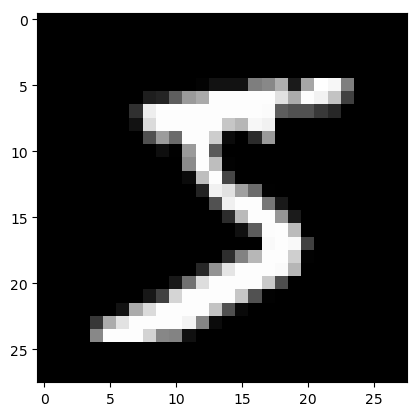

In [26]:
plt.imshow(image.reshape((28,28)),cmap='gray') #viridis color scale: still greyscale image

In [28]:
torch.manual_seed(101)

train_loader = DataLoader(train_data, batch_size=100, shuffle=True)

test_loader = DataLoader(test_data, batch_size=500, shuffle=False)

In [30]:
from torchvision.utils import make_grid
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}')) # FORMATTING

In [31]:
# FIRST BATCH
for images, labels in train_loader:
    break

In [33]:
images.shape

torch.Size([100, 1, 28, 28])

In [34]:
labels.shape

torch.Size([100])

Labels:  [   7    2    3    5    8    5    3    6    9    9    1    3]


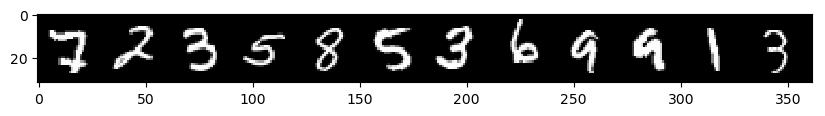

In [35]:
# Print the first 12 labels
print('Labels: ', labels[:12].numpy())

# Print the first 12 images
im = make_grid(images[:12], nrow=12)  # the default nrow is 8
plt.figure(figsize=(10,4))
# We need to transpose the images from CWH to WHC
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

In [37]:
class MultilayerPerceptron(nn.Module):
    
    def __init__(self,in_sz=784,out_sz=10, layers=[120, 84]):
        
        super().__init__()
        
        self.fc1 = nn.Linear(in_sz, layers[0])
        self.fc2 = nn.Linear(layers[0], layers[1])
        self.fc3 = nn.Linear(layers[1], out_sz)
        
    def forward(self, X):
    
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        
        return F.log_softmax(X, dim=1) # MULTI CLASS CLASSIFICATION

In [38]:
torch.manual_seed(101)
model = MultilayerPerceptron()

In [39]:
model

MultilayerPerceptron(
  (fc1): Linear(in_features=784, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [40]:
# ANN ---> CNN
for param in model.parameters():
    print(param.numel())


94080
120
10080
84
840
10


In [41]:
# 105,214 total parameters in ANN
# will be less in CNN

In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [44]:
images.shape # -----> [100, 784]

torch.Size([100, 1, 28, 28])

In [46]:
images.view(100, -1).shape # -1 combines all later parts of tensor

torch.Size([100, 784])

In [52]:
import time
start_time = time.time()

#TRAINING

epochs = 10 # arbitrary

# Trackers
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    
    trn_corr = 0
    tst_corr = 0
    
    for b, (X_train, y_train) in enumerate(train_loader):
        
        b+=1
        
        # 10 Neurons:
        # [0.1, 0, 0, 0, 0.9...]
        y_pred = model(X_train.view(100, -1))
        loss = criterion(y_pred, y_train)
        
        #Checks which number was predicted with highest probability
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if b%200 == 0:
            acc = trn_corr.item()*100/(100*b)
            print(f'Epoch {i}  batch{b} loss:{loss.item()}  accuracy:{acc}')
                  
    train_losses.append(loss)
    train_correct.append(trn_corr)
    
    with torch.no_grad():
        
        for b, (X_test, y_test) in enumerate(test_loader):
            
            y_val = model(X_test.view(500,-1))
            
            predicted = torch.max(y_val.data, 1)[1]
            tst_corr += (predicted==y_test).sum()
            
    loss = criterion(y_val,y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)              

total_time = time.time() - start_time
print(f'Duration: {total_time/60} mins')

Epoch 0  batch200 loss:0.23562383651733398  accuracy:83.245
Epoch 0  batch400 loss:0.3533070683479309  accuracy:87.5325
Epoch 0  batch600 loss:0.13734400272369385  accuracy:89.58166666666666
Epoch 1  batch200 loss:0.2468499392271042  accuracy:94.87
Epoch 1  batch400 loss:0.14273874461650848  accuracy:95.085
Epoch 1  batch600 loss:0.0733642652630806  accuracy:95.355
Epoch 2  batch200 loss:0.08374133706092834  accuracy:96.53
Epoch 2  batch400 loss:0.06233545392751694  accuracy:96.6175
Epoch 2  batch600 loss:0.060482099652290344  accuracy:96.71
Epoch 3  batch200 loss:0.11456042528152466  accuracy:97.645
Epoch 3  batch400 loss:0.054195836186409  accuracy:97.4725
Epoch 3  batch600 loss:0.032323505729436874  accuracy:97.50666666666666
Epoch 4  batch200 loss:0.11077029258012772  accuracy:98.125
Epoch 4  batch400 loss:0.049860574305057526  accuracy:97.9975
Epoch 4  batch600 loss:0.05137166380882263  accuracy:98.00333333333333
Epoch 5  batch200 loss:0.008783536963164806  accuracy:98.34
Epoch 5 

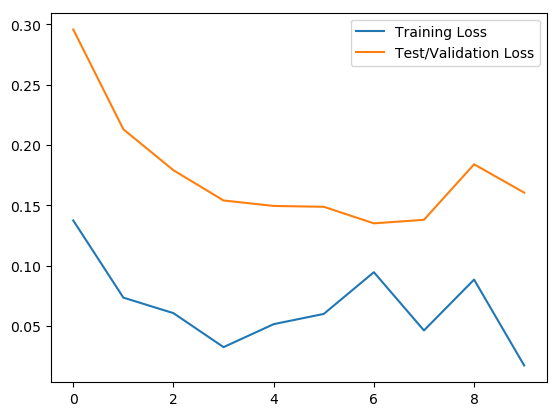

In [54]:
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test/Validation Loss')
plt.legend()

In [58]:
train_acc = [t/600 for t in train_correct]

In [60]:
train_acc

[tensor(89.5817),
 tensor(95.3550),
 tensor(96.7100),
 tensor(97.5067),
 tensor(98.0033),
 tensor(98.3467),
 tensor(98.6583),
 tensor(98.9250),
 tensor(99.0700),
 tensor(99.2550)]

In [61]:
test_acc = [t/100 for t in test_correct]

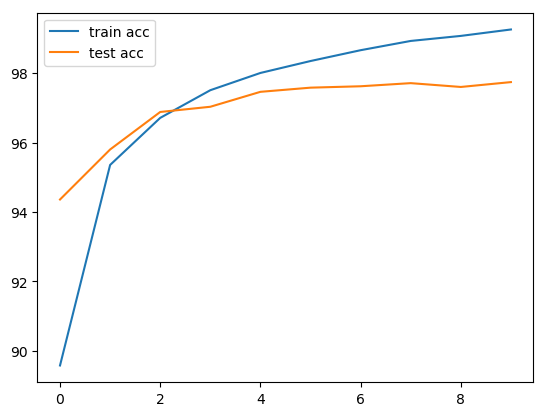

In [62]:
plt.plot(train_acc, label='train acc')
plt.plot(test_acc, label='test acc')
plt.legend()

In [65]:
# NEW UNSEEN DATA

test_load_all = DataLoader(test_data,batch_size=10000, shuffle=False)

In [69]:
with torch.no_grad():
    correct = 0

    for X_test, y_test in test_load_all:
        y_val= model(X_test.view(len(X_test), -1))
        predicted = torch.max(y_val, 1)[1]
        correct += (predicted==y_test).sum()

In [73]:
100*correct.item()/len(test_data)

97.74

In [75]:
confusion_matrix(predicted.view(-1), y_test.view(-1))

array([[ 975,    0,    6,    1,    1,    2,    6,    3,    5,    3],
       [   0, 1125,    3,    0,    0,    0,    3,    7,    0,    2],
       [   0,    3, 1001,    2,    1,    0,    2,    9,    3,    0],
       [   2,    3,    6,  984,    0,    9,    1,    1,    3,    3],
       [   0,    0,    2,    0,  967,    3,    3,    2,    3,    9],
       [   0,    1,    0,    8,    0,  865,    3,    1,    3,    2],
       [   1,    1,    1,    0,    4,    5,  939,    0,    1,    0],
       [   0,    0,    3,    5,    1,    0,    0,  982,    2,    0],
       [   2,    2,   10,    4,    0,    5,    1,    3,  949,    3],
       [   0,    0,    0,    6,    8,    3,    0,   20,    5,  987]],
      dtype=int64)